In [2]:
import joblib
import pandas as pd

# 1. Đọc dữ liệu thô
# Vì notebook eda.ipynb nằm trong thư mục src/, nên đường dẫn cần lùi 1 thư mục bằng '../'
data = pd.read_csv('../raw_data/data_merged.csv')
x = data.drop('TARGET', axis=1).copy()
y = data['TARGET'].copy()

# 2. Tải pipeline đã huấn luyện sẵn từ tệp pkl
pipeline = joblib.load('../models/full.pkl')

# 3. Cắt lát pipeline để chỉ lấy phần Tiền xử lý (loại bỏ mô hình LightGBM ở cuối)
preprocessor = pipeline[:-1]

# 4. Biến đổi dữ liệu thô sang dữ liệu sạch qua pipeline
print("Running preprocessing pipeline...")
x_prepped = preprocessor.transform(x)

# 5. Thêm lại cột TARGET vào tập dữ liệu sạch để tiện vẽ biểu đồ/tính tương quan
x_prepped['TARGET'] = y

print(f"Done! Clean dataset shape: {x_prepped.shape}")

Running preprocessing pipeline...
Feature encoding completed: data shape: (307511, 209)
Feature dropping completed, data shape; (307511, 163), feature dropped: 46
New features created: ['retired_or_unemployed', 'payment_rate', 'ext_std', 'credit_income_ratio', 'income_annuity_ratio', 'birth_employed_ratio', 'credit_goods_ratio', 'EXT_mean', 'high_default_risk']


c:\Users\minhq\miniconda3\envs\credit_scoring_system\Lib\site-packages\numpy\_core\fromnumeric.py:4026: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


Feature imputing completed.
Data scaled completed
Done! Clean dataset shape: (307511, 173)


In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train ,y_test = train_test_split(x, y, test_size=0.2, random_state= 42)

Feature encoding completed: data shape: (61503, 209)
Feature dropping completed, data shape; (61503, 163), feature dropped: 46
New features created: ['retired_or_unemployed', 'payment_rate', 'ext_std', 'credit_income_ratio', 'income_annuity_ratio', 'birth_employed_ratio', 'credit_goods_ratio', 'EXT_mean', 'high_default_risk']
Feature imputing completed.


c:\Users\minhq\miniconda3\envs\credit_scoring_system\Lib\site-packages\numpy\_core\fromnumeric.py:4026: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


Data scaled completed
ROC-AUC Score trên tập Test: 0.7788
Ngưỡng phân ngưỡng tối ưu (Youden Index): 0.4947
Tại ngưỡng này -> TPR (Recall): 70.36%, FPR: 28.57%


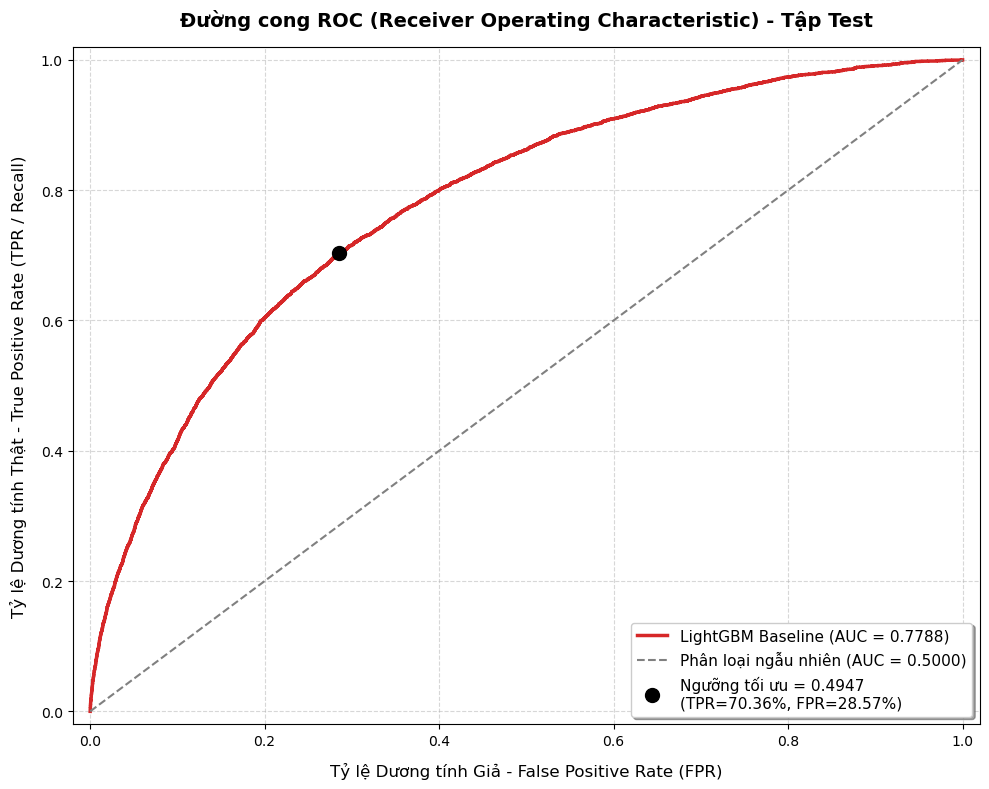

In [4]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
y_probs = pipeline.predict_proba(x_test)[:, 1]
# Tính toán giá trị ROC-AUC
auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score trên tập Test: {auc_score:.4f}")
# =====================================================================
# 3. Tính toán các điểm trên đường ROC Curve
# =====================================================================
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
# Tìm ngưỡng tối ưu (tối đa hóa Chỉ số Youden: TPR - FPR)
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
print(f"Ngưỡng phân ngưỡng tối ưu (Youden Index): {optimal_threshold:.4f}")
print(f"Tại ngưỡng này -> TPR (Recall): {tpr[optimal_idx]:.2%}, FPR: {fpr[optimal_idx]:.2%}")
# =====================================================================
# 4. Trực quan hóa ROC Curve
# =====================================================================
plt.figure(figsize=(10, 8))
# Vẽ đường ROC của mô hình
plt.plot(
    fpr, tpr, 
    color='#d62728', 
    lw=2.5, 
    label=f'LightGBM Baseline (AUC = {auc_score:.4f})'
)
# Vẽ đường chéo tham chiếu của mô hình phân loại ngẫu nhiên (Random Classifier)
plt.plot(
    [0, 1], [0, 1], 
    color='gray', 
    linestyle='--', 
    lw=1.5, 
    label='Phân loại ngẫu nhiên (AUC = 0.5000)'
)
# Đánh dấu điểm ngưỡng tối ưu (Youden)
plt.scatter(
    fpr[optimal_idx], tpr[optimal_idx], 
    color='black', 
    s=100, 
    zorder=5, 
    label=f'Ngưỡng tối ưu = {optimal_threshold:.4f}\n(TPR={tpr[optimal_idx]:.2%}, FPR={fpr[optimal_idx]:.2%})'
)
# Định dạng biểu đồ
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Tỷ lệ Dương tính Giả - False Positive Rate (FPR)', fontsize=12, labelpad=10)
plt.ylabel('Tỷ lệ Dương tính Thật - True Positive Rate (TPR / Recall)', fontsize=12, labelpad=10)
plt.title('Đường cong ROC (Receiver Operating Characteristic) - Tập Test', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

=== BẢNG TRA CỨU NGƯỠNG THEO RECALL MỤC TIÊU ===
Threshold Recall (Tỷ lệ bắt nợ xấu) Precision (Độ chuẩn xác) FPR (Tỷ lệ bắt nhầm khách tốt)
   0.4965                    70.05%                   17.79%                         28.33%
   0.4515                    75.11%                   16.18%                         34.04%
   0.4066                    80.18%                   14.87%                         40.16%
   0.3536                    85.13%                   13.43%                         48.01%
   0.2977                    90.12%                   12.02%                         57.71%
   0.2268                    95.01%                   10.34%                         72.07%


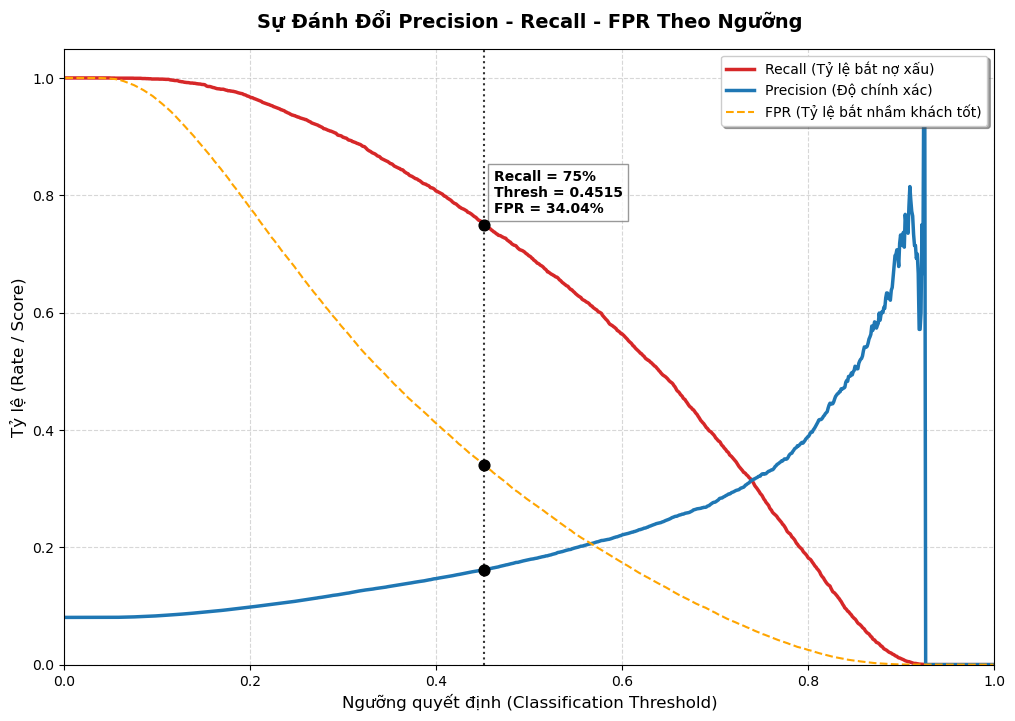

In [6]:

from sklearn.metrics import confusion_matrix

# =====================================================================
# 1. Định nghĩa danh sách các mốc Recall mục tiêu
# =====================================================================
target_recalls = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
tradeoff_results = []

# Quét qua 1000 ngưỡng từ 0.001 đến 0.999 để có độ mịn cao nhất
threshold_grid = np.linspace(0.001, 0.999, 1000)

for thresh in threshold_grid:
    # Dự báo nhãn dựa trên ngưỡng hiện tại
    y_pred_temp = (y_probs >= thresh).astype(int)
    
    # Tính Ma trận nhầm lẫn (Confusion Matrix)
    # tn: True Negative (Khách tốt - duyệt đúng)
    # fp: False Positive (Khách tốt - từ chối nhầm / bắt nhầm)
    # fn: False Negative (Khách xấu - duyệt nhầm / bỏ sót)
    # tp: True Positive (Khách xấu - từ chối đúng / bắt đúng)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
    
    # Tính toán các chỉ số
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0       # TPR
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0   # Precision
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0           # Tỷ lệ bắt nhầm khách tốt
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    tradeoff_results.append({
        'Threshold': thresh,
        'Recall (Tỷ lệ bắt nợ xấu)': recall,
        'Precision (Độ chuẩn xác)': precision,
        'FPR (Tỷ lệ bắt nhầm khách tốt)': fpr,
        'F1-Score': f1,
        'Approved_Good_Customers': tn,    # Số khách tốt được duyệt vay
        'Rejected_Good_Customers': fp,    # Số khách tốt bị từ chối nhầm
        'Approved_Bad_Customers': fn,     # Số khách xấu bị bỏ sót
        'Rejected_Bad_Customers': tp      # Số khách xấu bị bắt đúng
    })

df_tradeoff = pd.DataFrame(tradeoff_results)

# =====================================================================
# 2. Tìm ngưỡng tối ưu cho các mốc Recall mục tiêu
# =====================================================================
target_rows = []
for target in target_recalls:
    # Lấy dòng có Recall gần nhất nhưng LỚN HƠN hoặc BẰNG mức mục tiêu
    candidates = df_tradeoff[df_tradeoff['Recall (Tỷ lệ bắt nợ xấu)'] >= target]
    if not candidates.empty:
        # Chọn ngưỡng cao nhất có thể trong nhóm thỏa mãn để hạn chế tối đa việc bắt nhầm
        optimal_row = candidates.sort_values(by='Threshold', ascending=False).iloc[0]
        target_rows.append(optimal_row)

df_target_thresholds = pd.DataFrame(target_rows).reset_index(drop=True)

print("=== BẢNG TRA CỨU NGƯỠNG THEO RECALL MỤC TIÊU ===")
print(df_target_thresholds[['Threshold', 'Recall (Tỷ lệ bắt nợ xấu)', 'Precision (Độ chuẩn xác)', 'FPR (Tỷ lệ bắt nhầm khách tốt)']].to_string(index=False, formatters={
    'Threshold': '{:,.4f}'.format,
    'Recall (Tỷ lệ bắt nợ xấu)': '{:.2%}'.format,
    'Precision (Độ chuẩn xác)': '{:.2%}'.format,
    'FPR (Tỷ lệ bắt nhầm khách tốt)': '{:.2%}'.format
}))

# =====================================================================
# 3. Trực quan hóa Sự Đánh Đổi (Trade-off) giữa Recall và Precision
# =====================================================================
plt.figure(figsize=(12, 8))

# Vẽ đường Recall và Precision theo ngưỡng
plt.plot(df_tradeoff['Threshold'], df_tradeoff['Recall (Tỷ lệ bắt nợ xấu)'], label='Recall (Tỷ lệ bắt nợ xấu)', color='#d62728', lw=2.5)
plt.plot(df_tradeoff['Threshold'], df_tradeoff['Precision (Độ chuẩn xác)'], label='Precision (Độ chính xác)', color='#1f77b4', lw=2.5)
plt.plot(df_tradeoff['Threshold'], df_tradeoff['FPR (Tỷ lệ bắt nhầm khách tốt)'], label='FPR (Tỷ lệ bắt nhầm khách tốt)', color='orange', linestyle='--', lw=1.5)

# Đánh dấu các mốc Recall quan trọng trên biểu đồ (Ví dụ mốc 85% Recall)
target_recall_demo = 0.75
demo_row = df_target_thresholds[df_target_thresholds['Recall (Tỷ lệ bắt nợ xấu)'] >= target_recall_demo].iloc[0]
demo_thresh = demo_row['Threshold']
demo_prec = demo_row['Precision (Độ chuẩn xác)']
demo_fpr = demo_row['FPR (Tỷ lệ bắt nhầm khách tốt)']

# Vẽ đường gióng đứng cho ngưỡng demo
plt.axvline(x=demo_thresh, color='black', linestyle=':', alpha=0.8)
plt.scatter([demo_thresh, demo_thresh, demo_thresh], [target_recall_demo, demo_prec, demo_fpr], color='black', s=60, zorder=5)

plt.text(
    demo_thresh + 0.01, target_recall_demo + 0.02, 
    f"Recall = {target_recall_demo:.0%}\nThresh = {demo_thresh:.4f}\nFPR = {demo_fpr:.2%}", 
    fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

# Định dạng đồ thị
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('Ngưỡng quyết định (Classification Threshold)', fontsize=12)
plt.ylabel('Tỷ lệ (Rate / Score)', fontsize=12)
plt.title('Sự Đánh Đổi Precision - Recall - FPR Theo Ngưỡng', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Mean: 1.0410521900029592, std: 7.115216916226522, median: 0.0


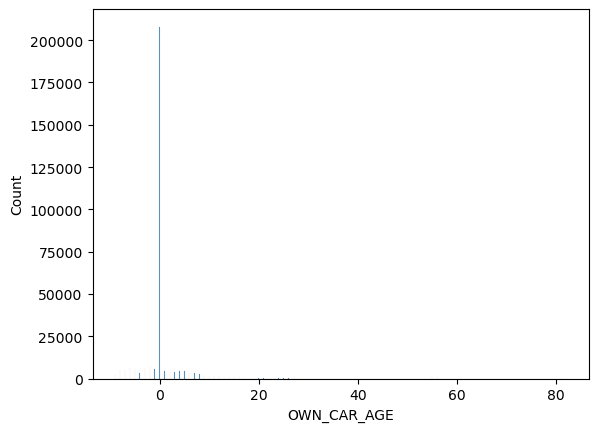

In [13]:
import seaborn as sns
x = x_prepped.copy()
print(f"Mean: {np.mean(x['OWN_CAR_AGE'])}, std: {np.std(x['OWN_CAR_AGE'])}, median: {np.median(x['OWN_CAR_AGE'])}")
sns.histplot(data = x, x= 'OWN_CAR_AGE')
plt.show()

In [18]:
from data_ingestion import DataLoader
file_path = "../raw_data/HomeCredit_columns_descriptions.csv"
column_discription = pd.read_csv("../raw_data/HomeCredit_columns_description.csv", encoding= 'latin1')
column_discription

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
...,...,...,...,...,...
214,217,installments_payments.csv,NUM_INSTALMENT_NUMBER,On which installment we observe payment,NaN
215,218,installments_payments.csv,DAYS_INSTALMENT,When the installment of previous credit was su...,time only relative to the application
216,219,installments_payments.csv,DAYS_ENTRY_PAYMENT,When was the installments of previous credit p...,time only relative to the application
217,220,installments_payments.csv,AMT_INSTALMENT,What was the prescribed installment amount of ...,NaN


In [ ]:
from data_ingestion import DataLoader
data_merged = DataLoader.merge_auxiliary_data(data, '../raw_data)
data_merged.shape

TypeError: DataLoader.merge_auxiliary_data() got an unexpected keyword argument 'index'

In [8]:
data_merged.to_csv('../raw_data/data_merged.csv', index= False)

In [9]:
from data_preprocessing import SchemaCreating
loader = SchemaCreating()
loader.fit_from_csv(file_path='../raw_data/data_merged.csv')
loader.save_to_json("../config/data_schema_full.json")

File data_merged.csv is loaded successfully, data shape: (1000, 180)
File is successfully classified
